In [1]:
import sys 
import os

In [5]:
current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, "../.."))
sys.path.insert(0, project_root)

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [7]:
from utils.plots import plot_categorical_data, plot_numerical_data

# Read Dataset

In [8]:
file = r'..\data\processed\train_features.parquet'

df = pd.read_parquet(file)

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Ticket_1p,Cabin_1p,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A521171,7.2500,None,S,Mr,A,None,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC17599,71.2833,C85,C,Mrs,P,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STONO23101282,7.9250,None,S,Miss,S,None,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,C123,S,Mrs,1,C,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,None,S,Mr,3,None,1,1


In [10]:
df['Cabin_1p'].unique()

array([None, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [11]:
print(f'Dataset rows and columns: {df.shape}')

Dataset rows and columns: (891, 17)


In [12]:
# Selecionando as variáveis categóricas

cat_var = df.select_dtypes(include=['category','object', 'bool']).columns
cat_var

Index(['Pclass', 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Title',
       'Ticket_1p', 'Cabin_1p'],
      dtype='object')

In [13]:
num_var = df.select_dtypes(include=['number']).columns
num_var

Index(['PassengerId', 'Survived', 'Age', 'SibSp', 'Parch', 'Fare',
       'FamilySize', 'IsAlone'],
      dtype='object')

# Check target - Y_true

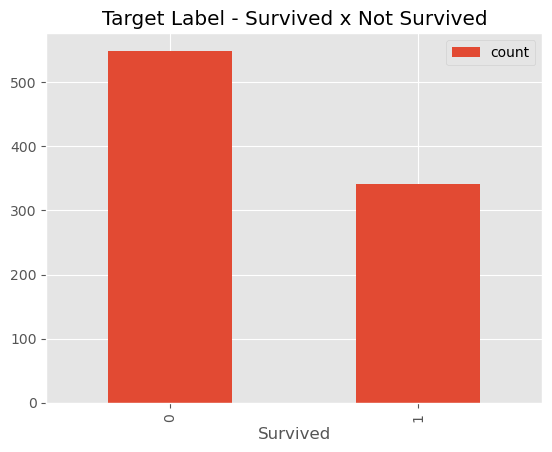

In [14]:
# verificar quantidade de labels por target

df['Survived'].value_counts().plot.bar()
plt.title('Target Label - Survived x Not Survived')
plt.legend()
plt.show()

# Exploratory Analisys

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    float64
 7   Parch        891 non-null    float64
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Title        891 non-null    object 
 13  Ticket_1p    891 non-null    object 
 14  Cabin_1p     204 non-null    object 
 15  FamilySize   891 non-null    int64  
 16  IsAlone      891 non-null    int32  
dtypes: float64(4), int32(1), int64(3), object(9)
memory usage: 115.0+ KB


# Check NA values

<Axes: >

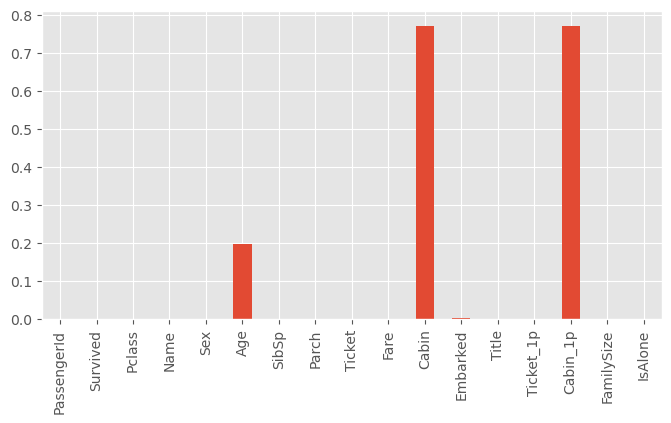

In [16]:
df.isna().mean().plot.bar(figsize=(8,4))

# Check Cardinality

In [17]:
for col in cat_var:
    print('labels por variável: ' + col + ' ' + str(df[col].nunique()))

labels por variável: Pclass 3
labels por variável: Name 891
labels por variável: Sex 2
labels por variável: Ticket 681
labels por variável: Cabin 147
labels por variável: Embarked 3
labels por variável: Title 5
labels por variável: Ticket_1p 16
labels por variável: Cabin_1p 8


In [18]:
for col in num_var:
    print('Numero de labels por variável na coluna: ' + col + ' ' + str(df[col].nunique()))

Numero de labels por variável na coluna: PassengerId 891
Numero de labels por variável na coluna: Survived 2
Numero de labels por variável na coluna: Age 88
Numero de labels por variável na coluna: SibSp 7
Numero de labels por variável na coluna: Parch 7
Numero de labels por variável na coluna: Fare 248
Numero de labels por variável na coluna: FamilySize 9
Numero de labels por variável na coluna: IsAlone 2


# Drop constant features
- nao tem variável constante

# Drop Features

In [19]:
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Ticket_1p'], inplace=True) # variável sem valor de predicao

In [20]:
# renew dtype
num_var = df.select_dtypes(include=['number']).columns
cat_var = df.select_dtypes(include=['object', 'category', 'bool']).columns

# Plots

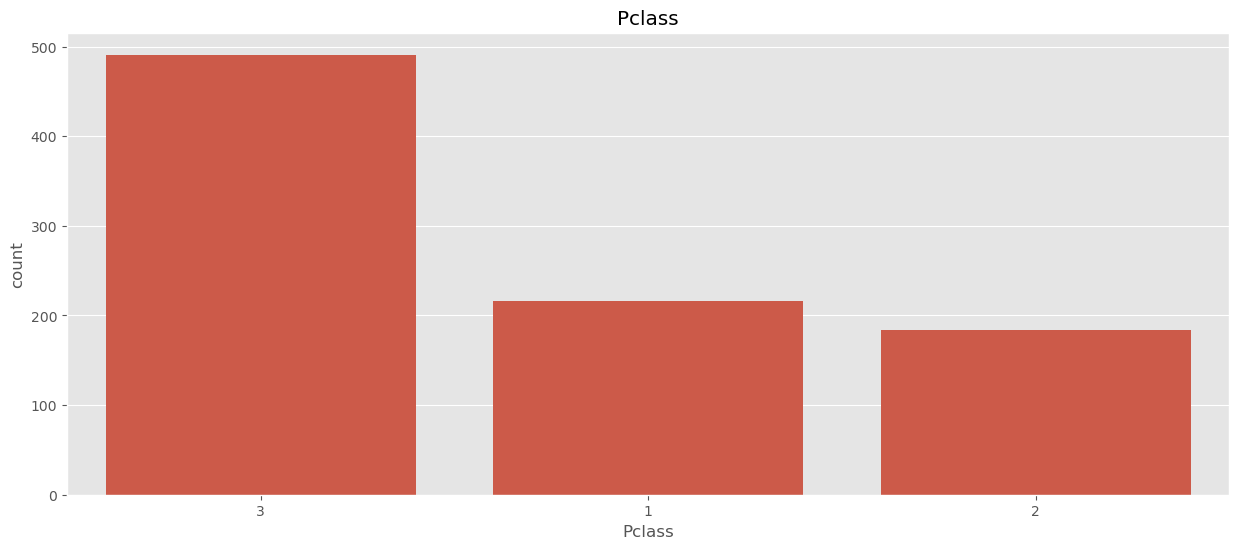

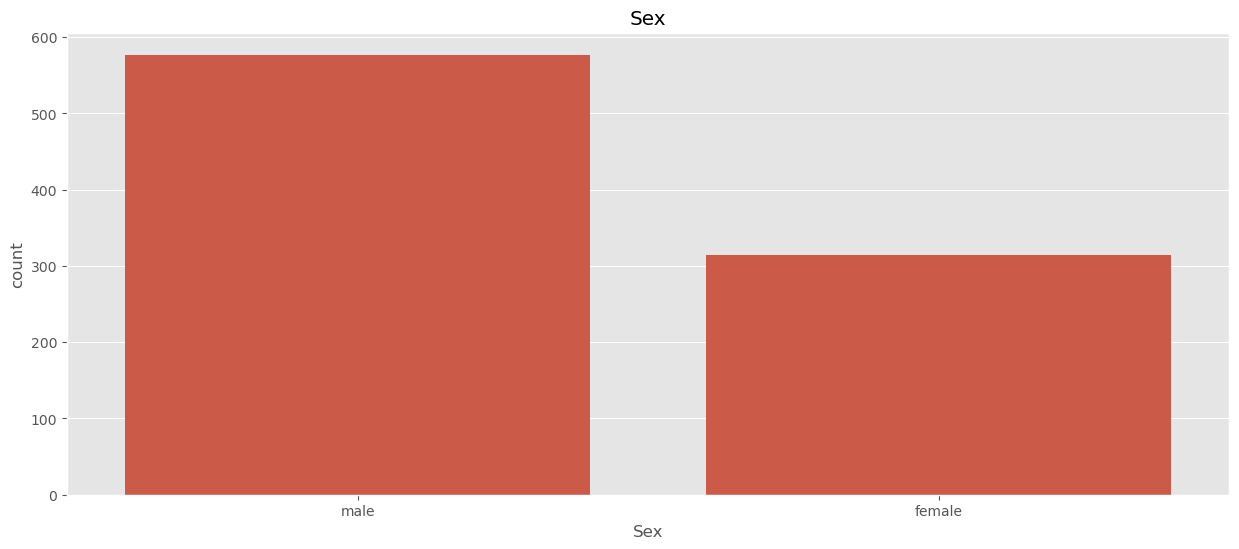

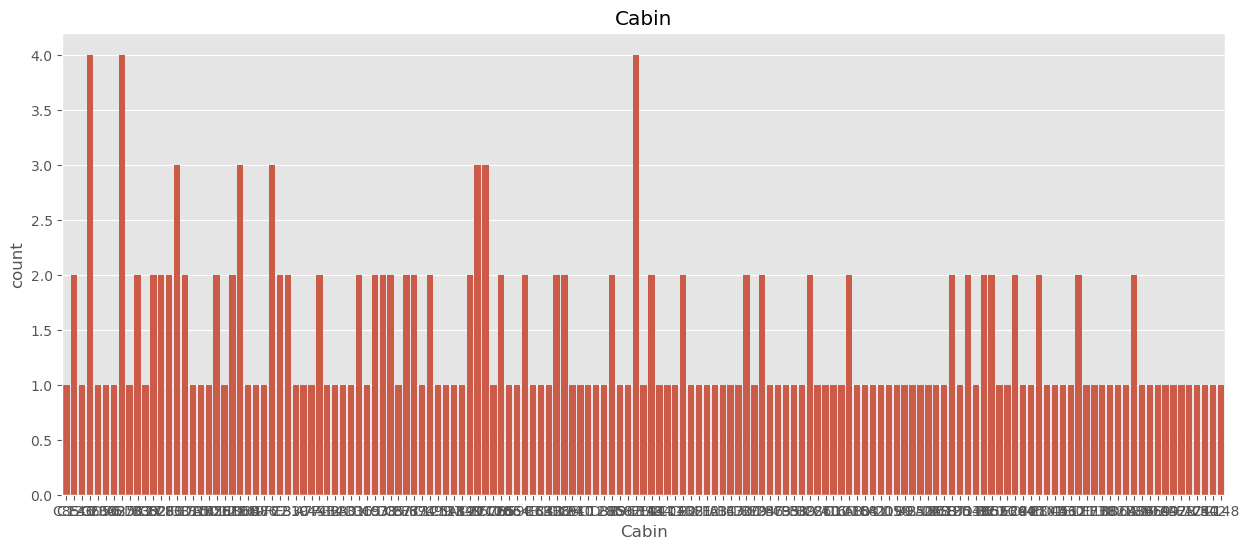

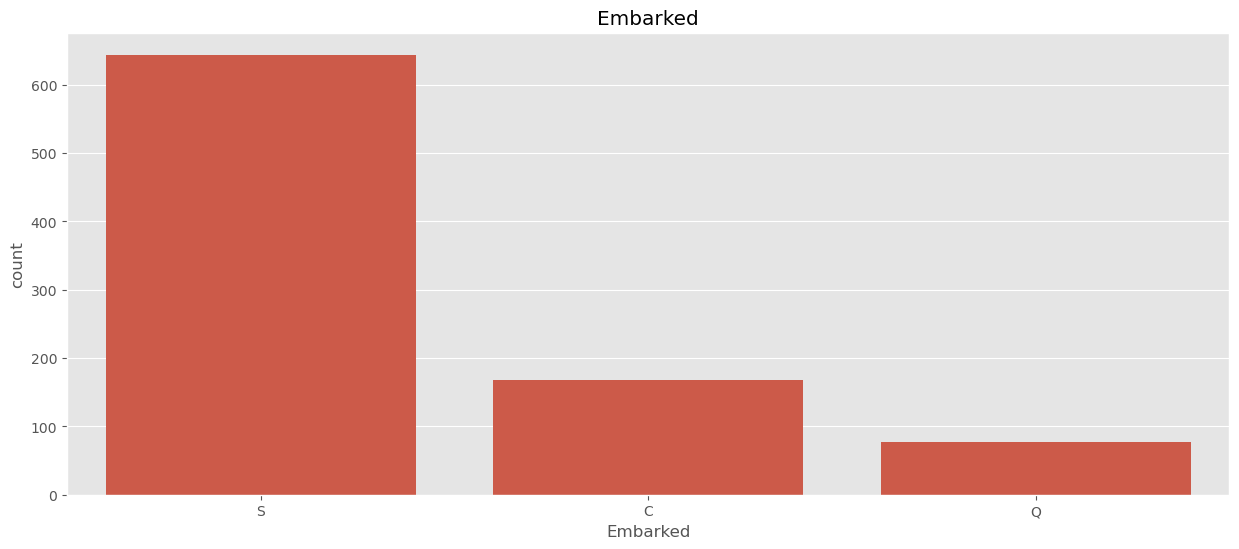

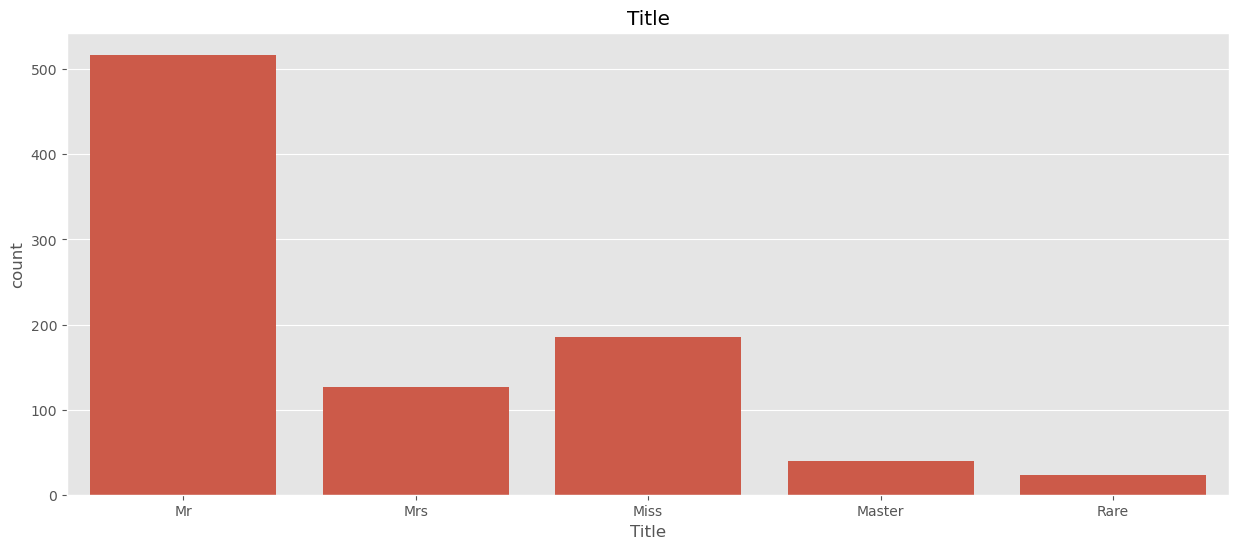

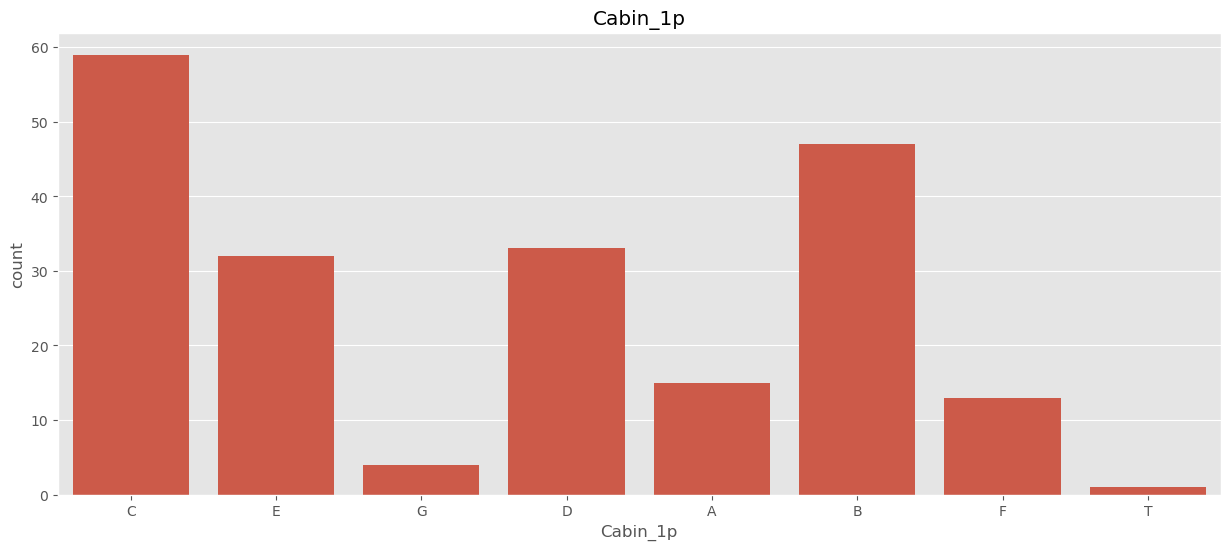

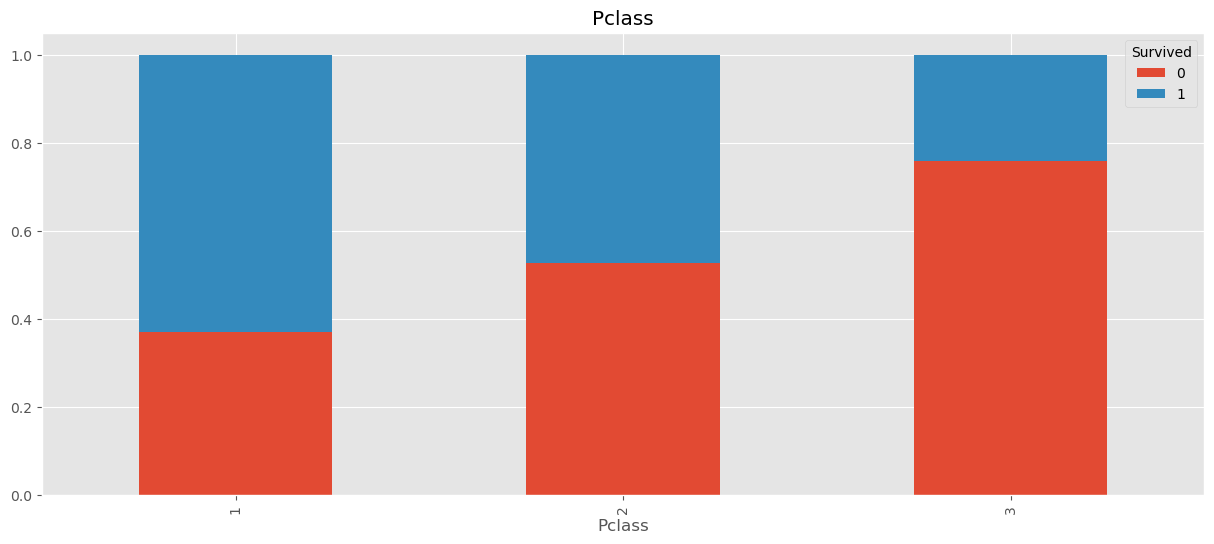

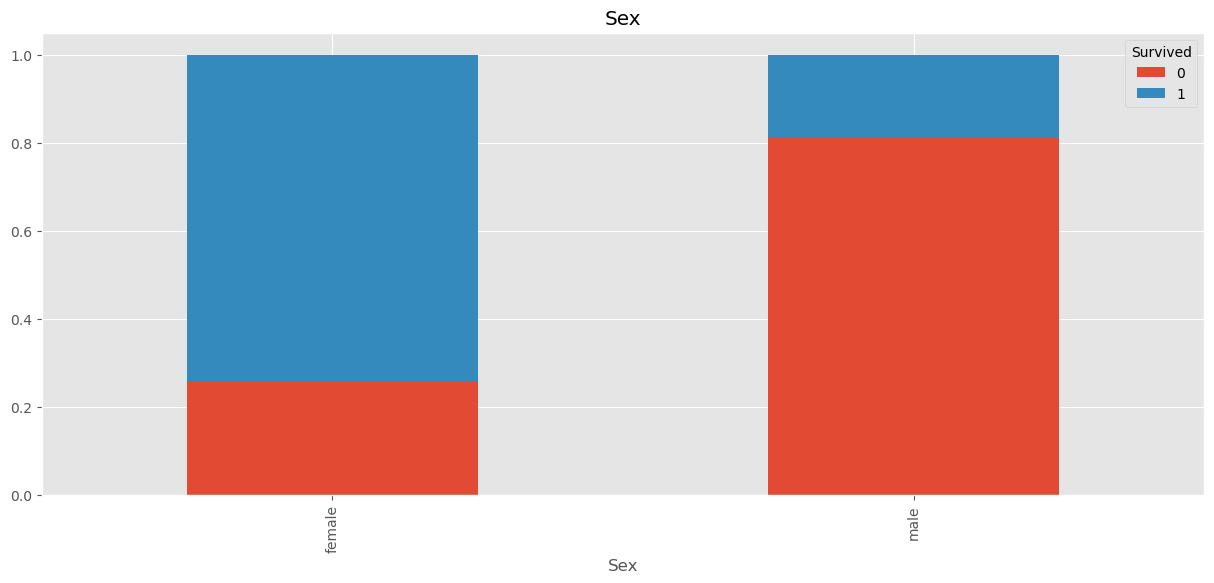

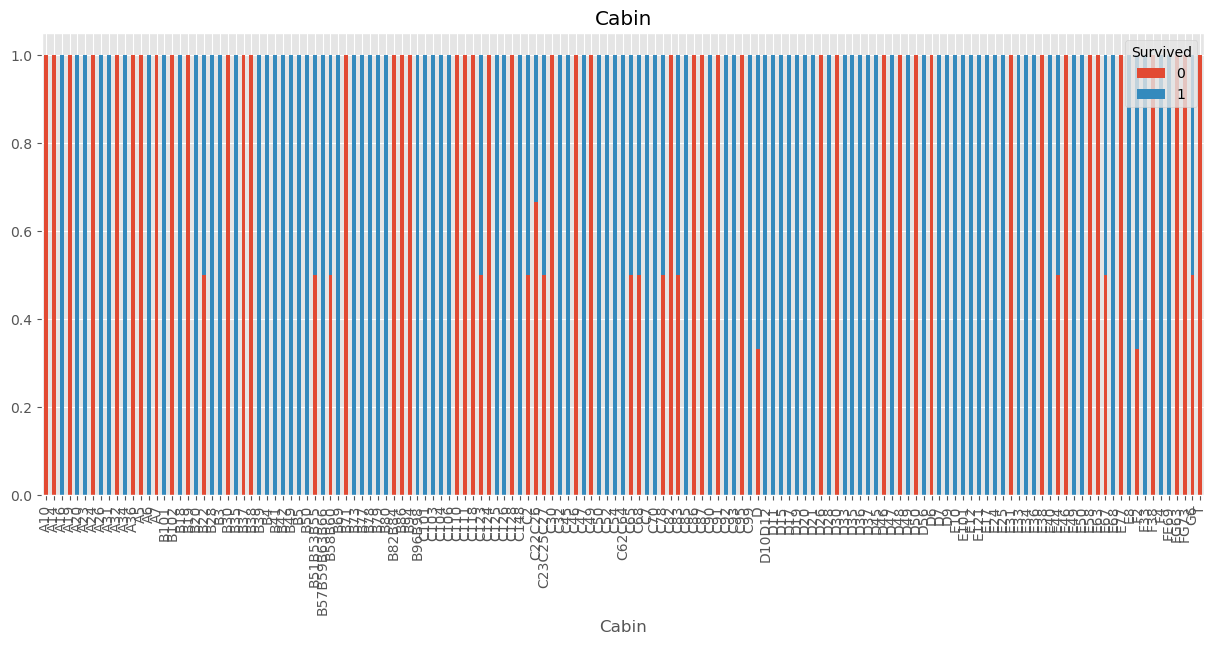

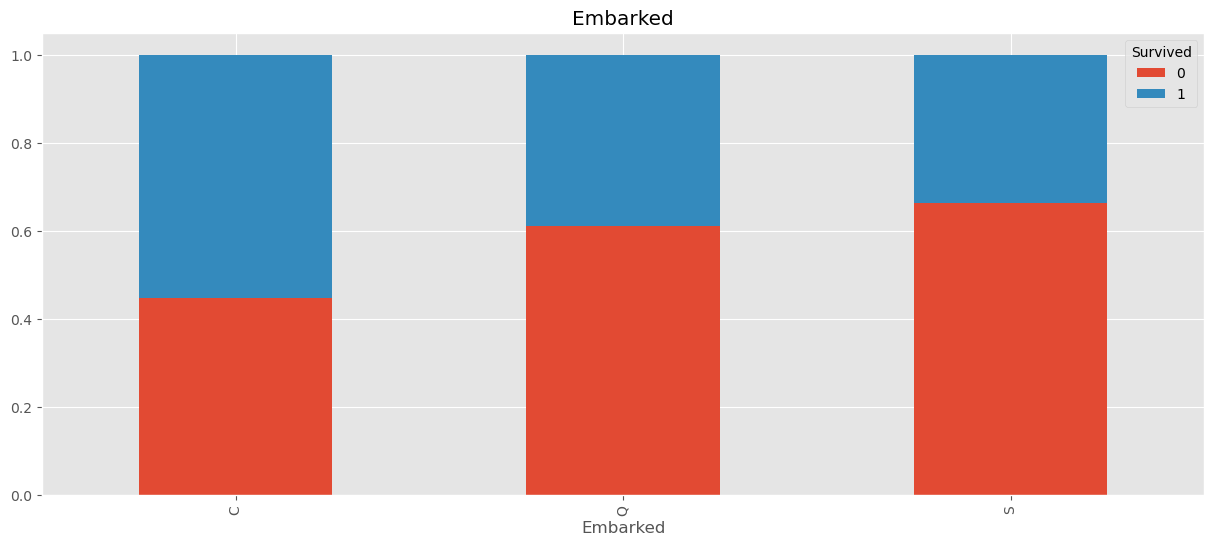

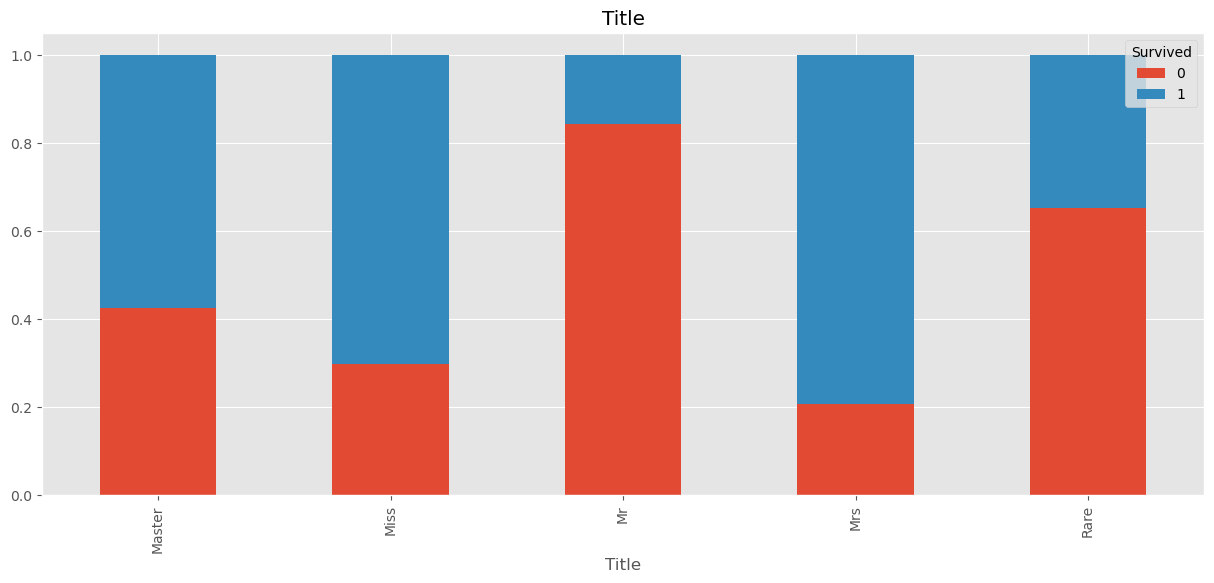

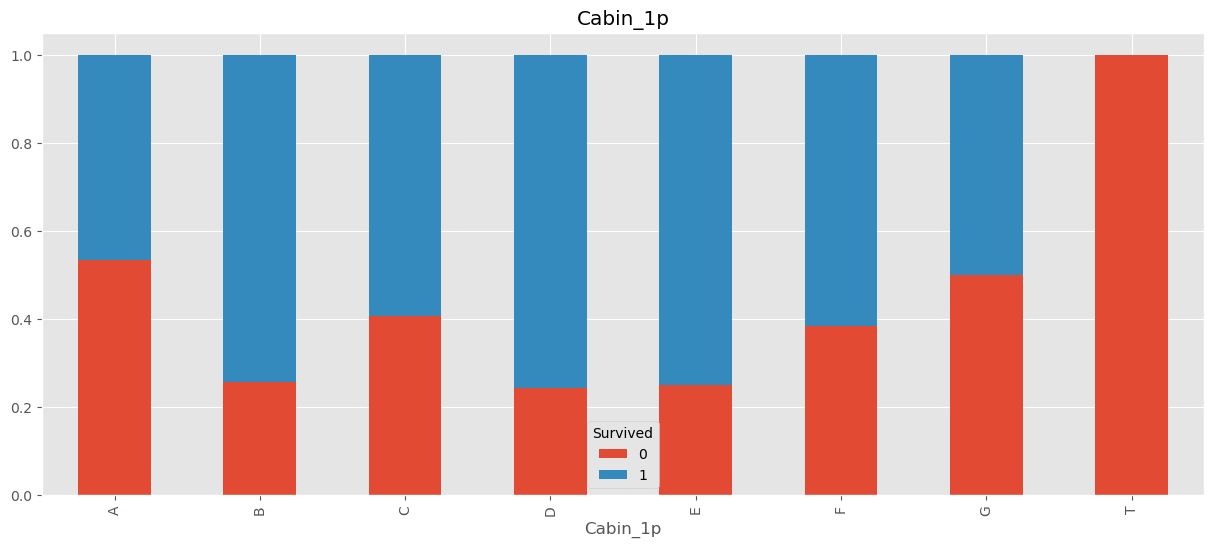

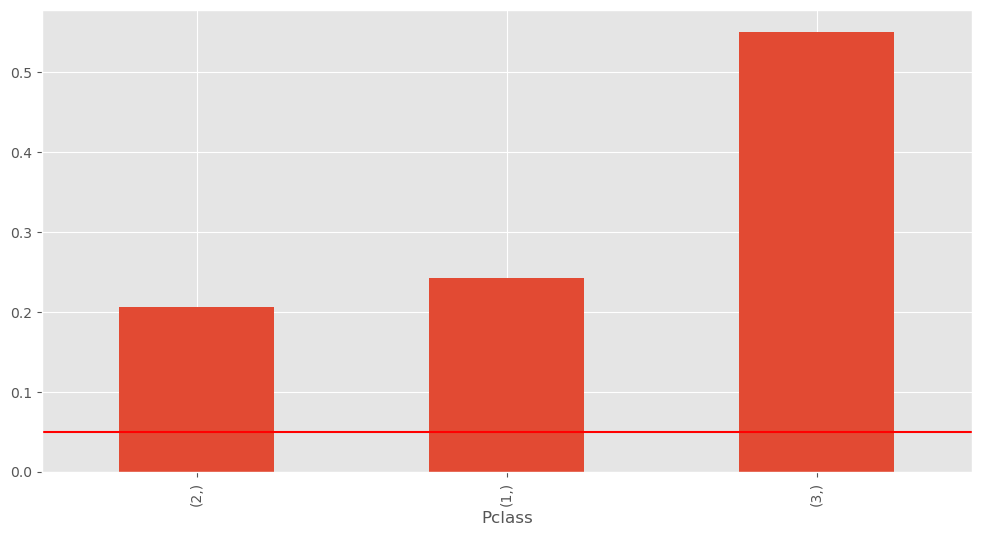

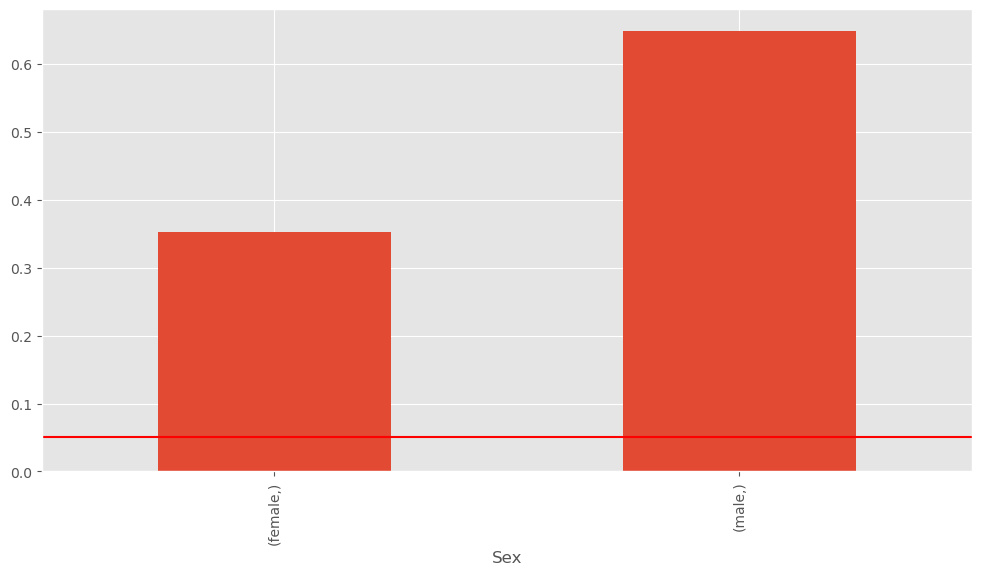

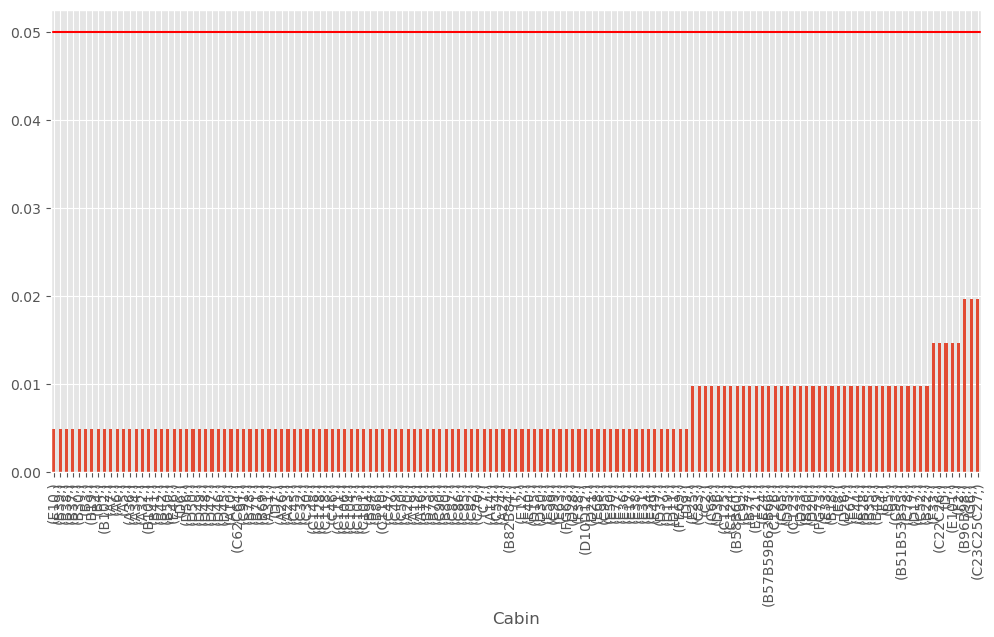

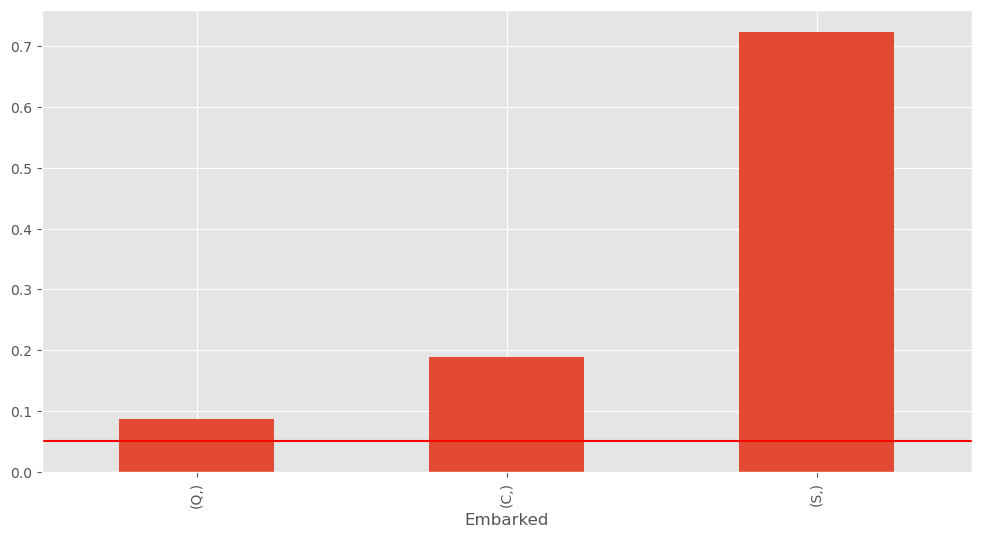

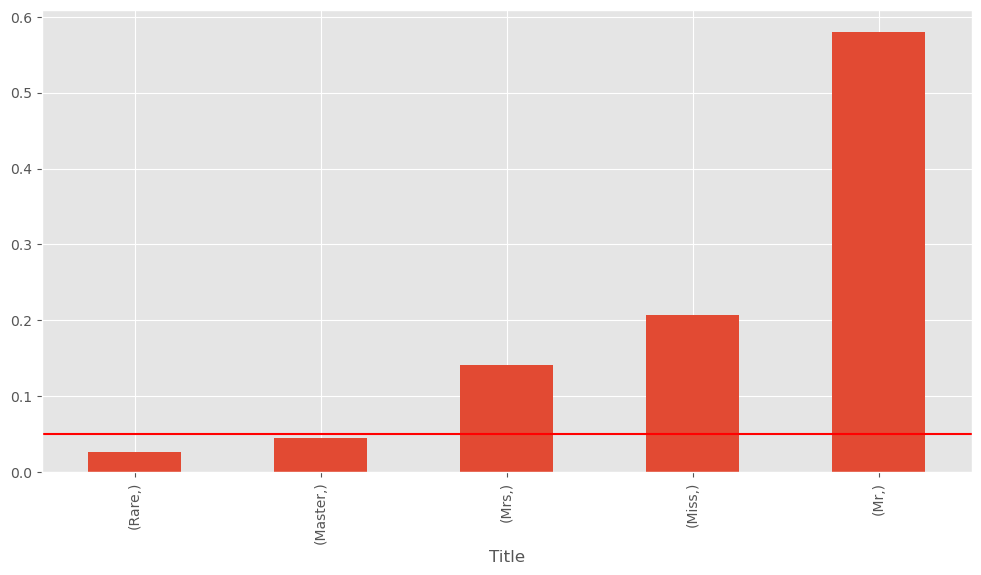

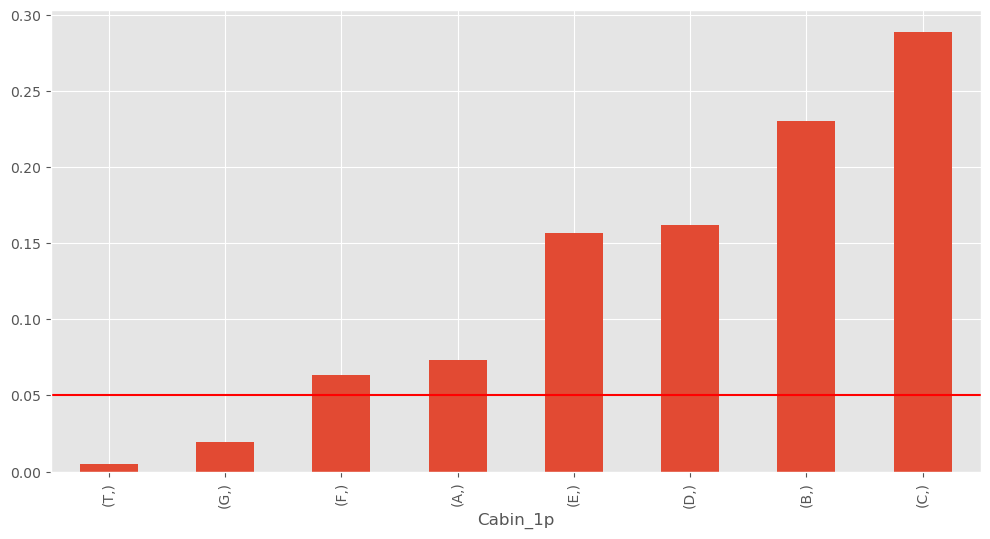

In [21]:
plot_categorical_data(df=df, target="Survived")

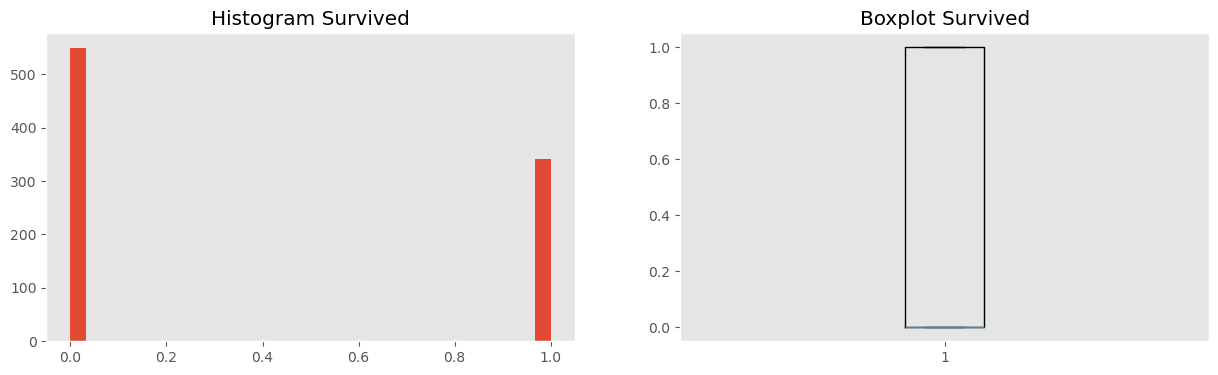

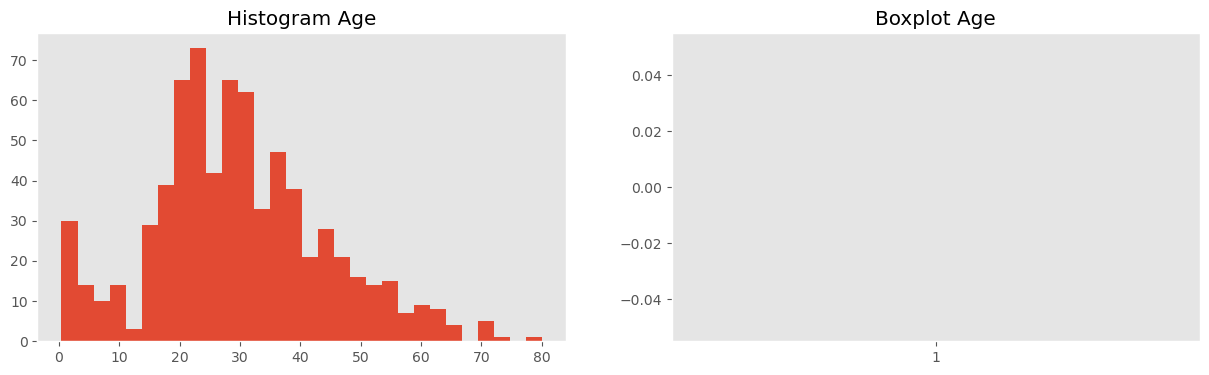

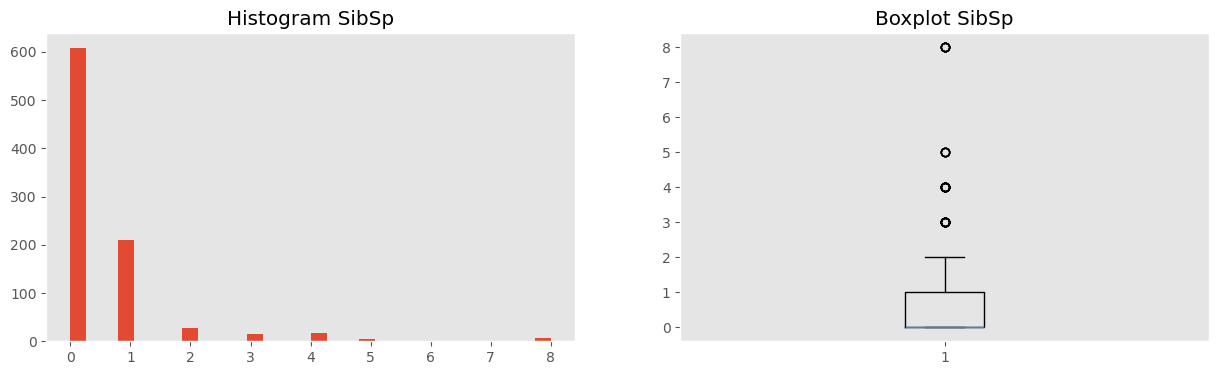

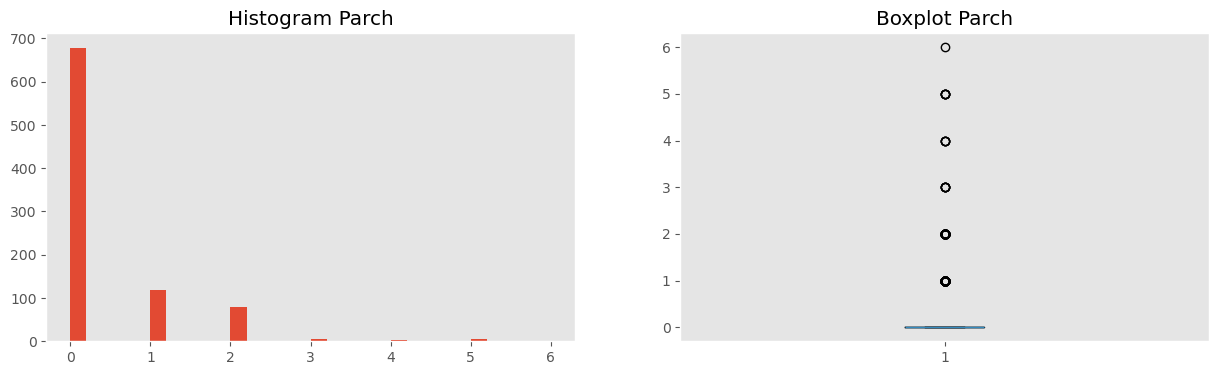

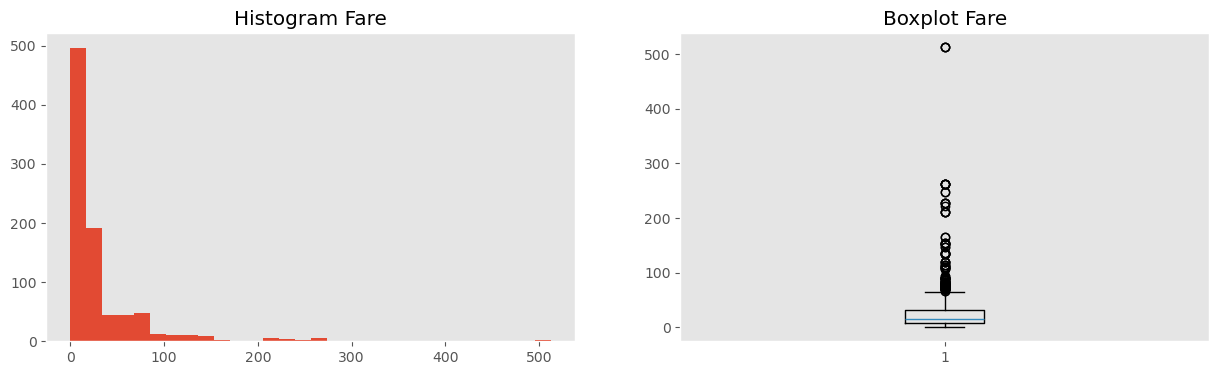

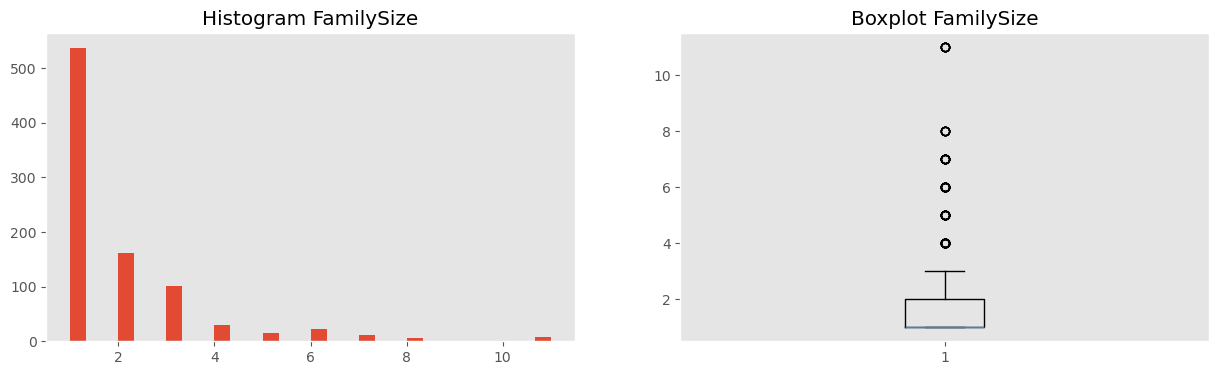

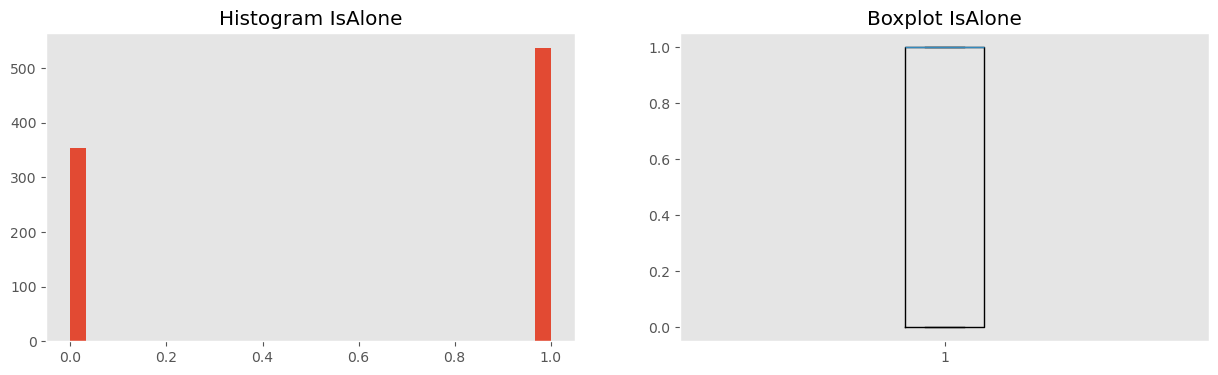

c:\Users\gustavo\Documents\Data Science\08-GitHub\kaggle\utils\plots.py:82: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


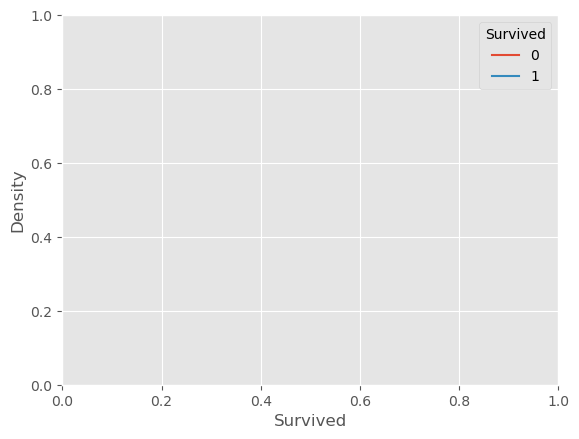

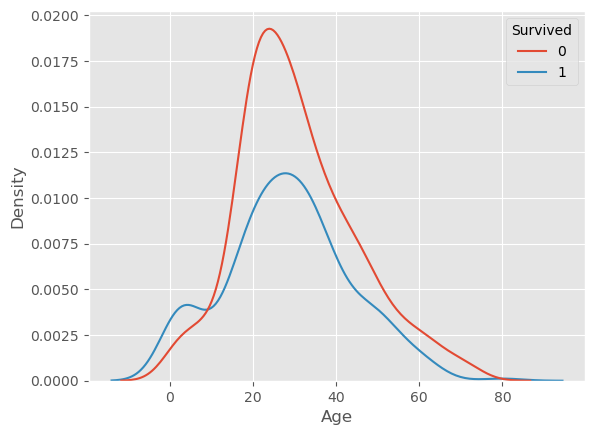

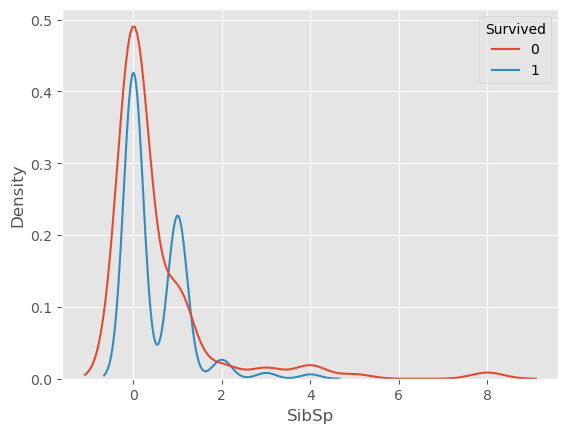

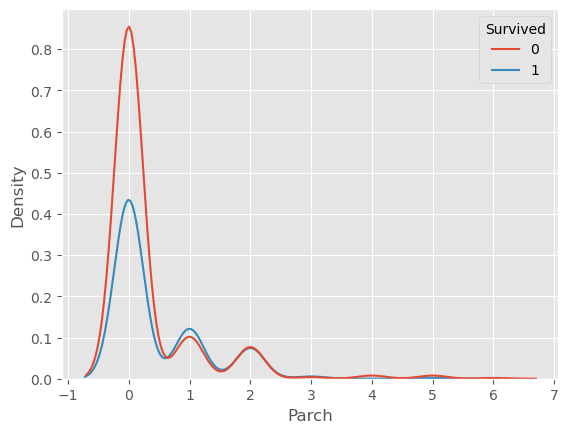

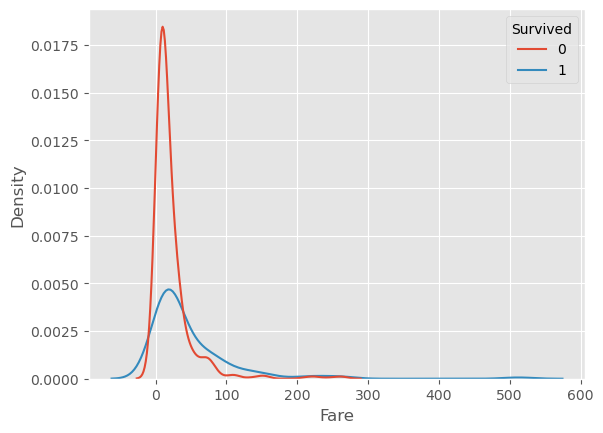

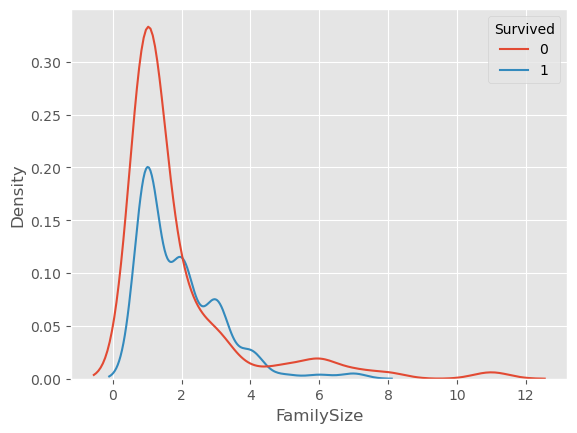

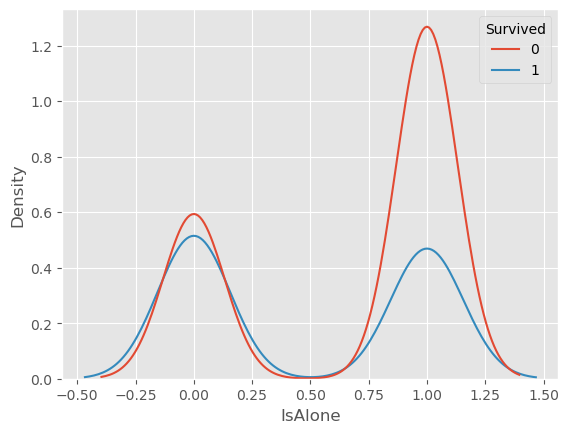

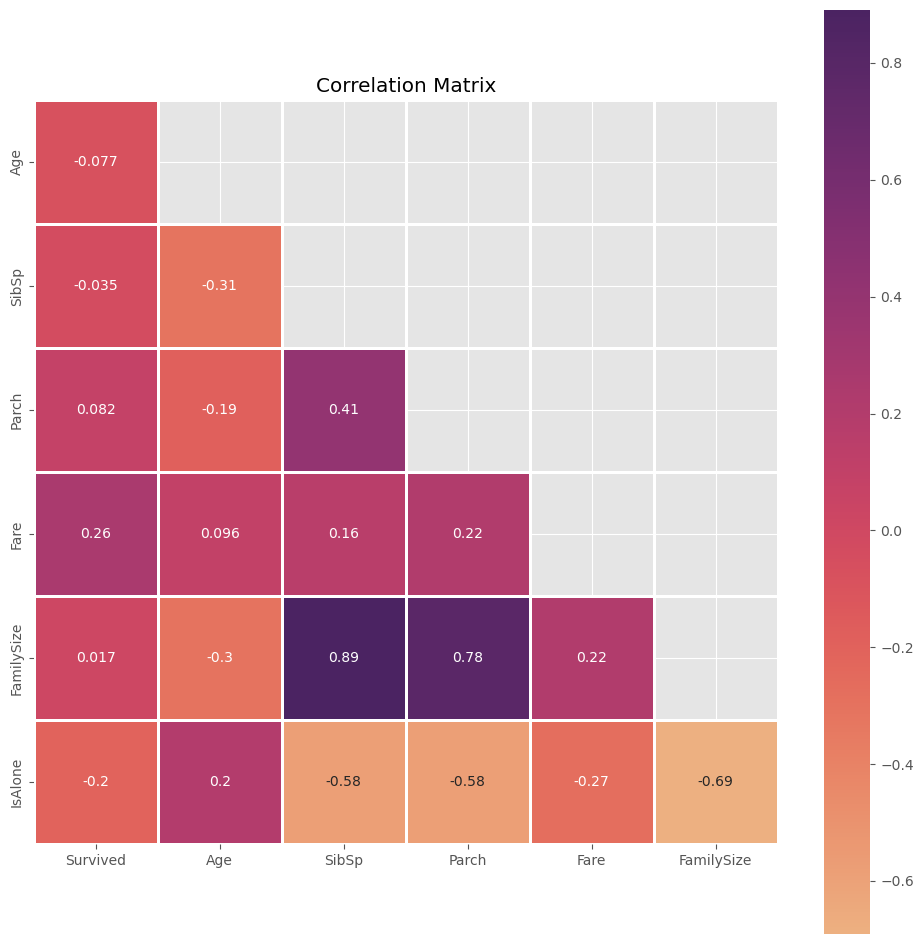

In [22]:
plot_numerical_data(df, target="Survived")

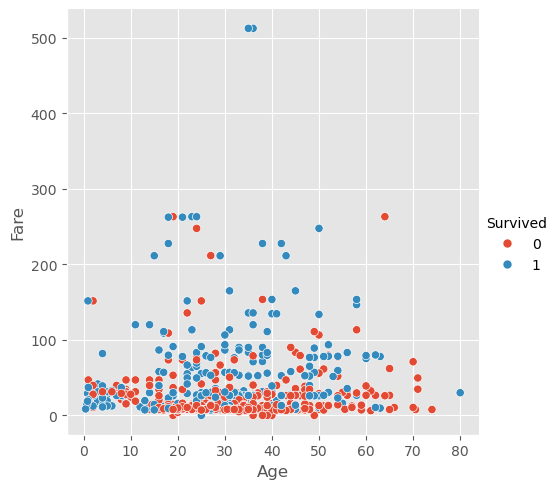

In [23]:
sns.relplot(
    data=df,
    x='Age',
    y='Fare',
    hue='Survived'
)

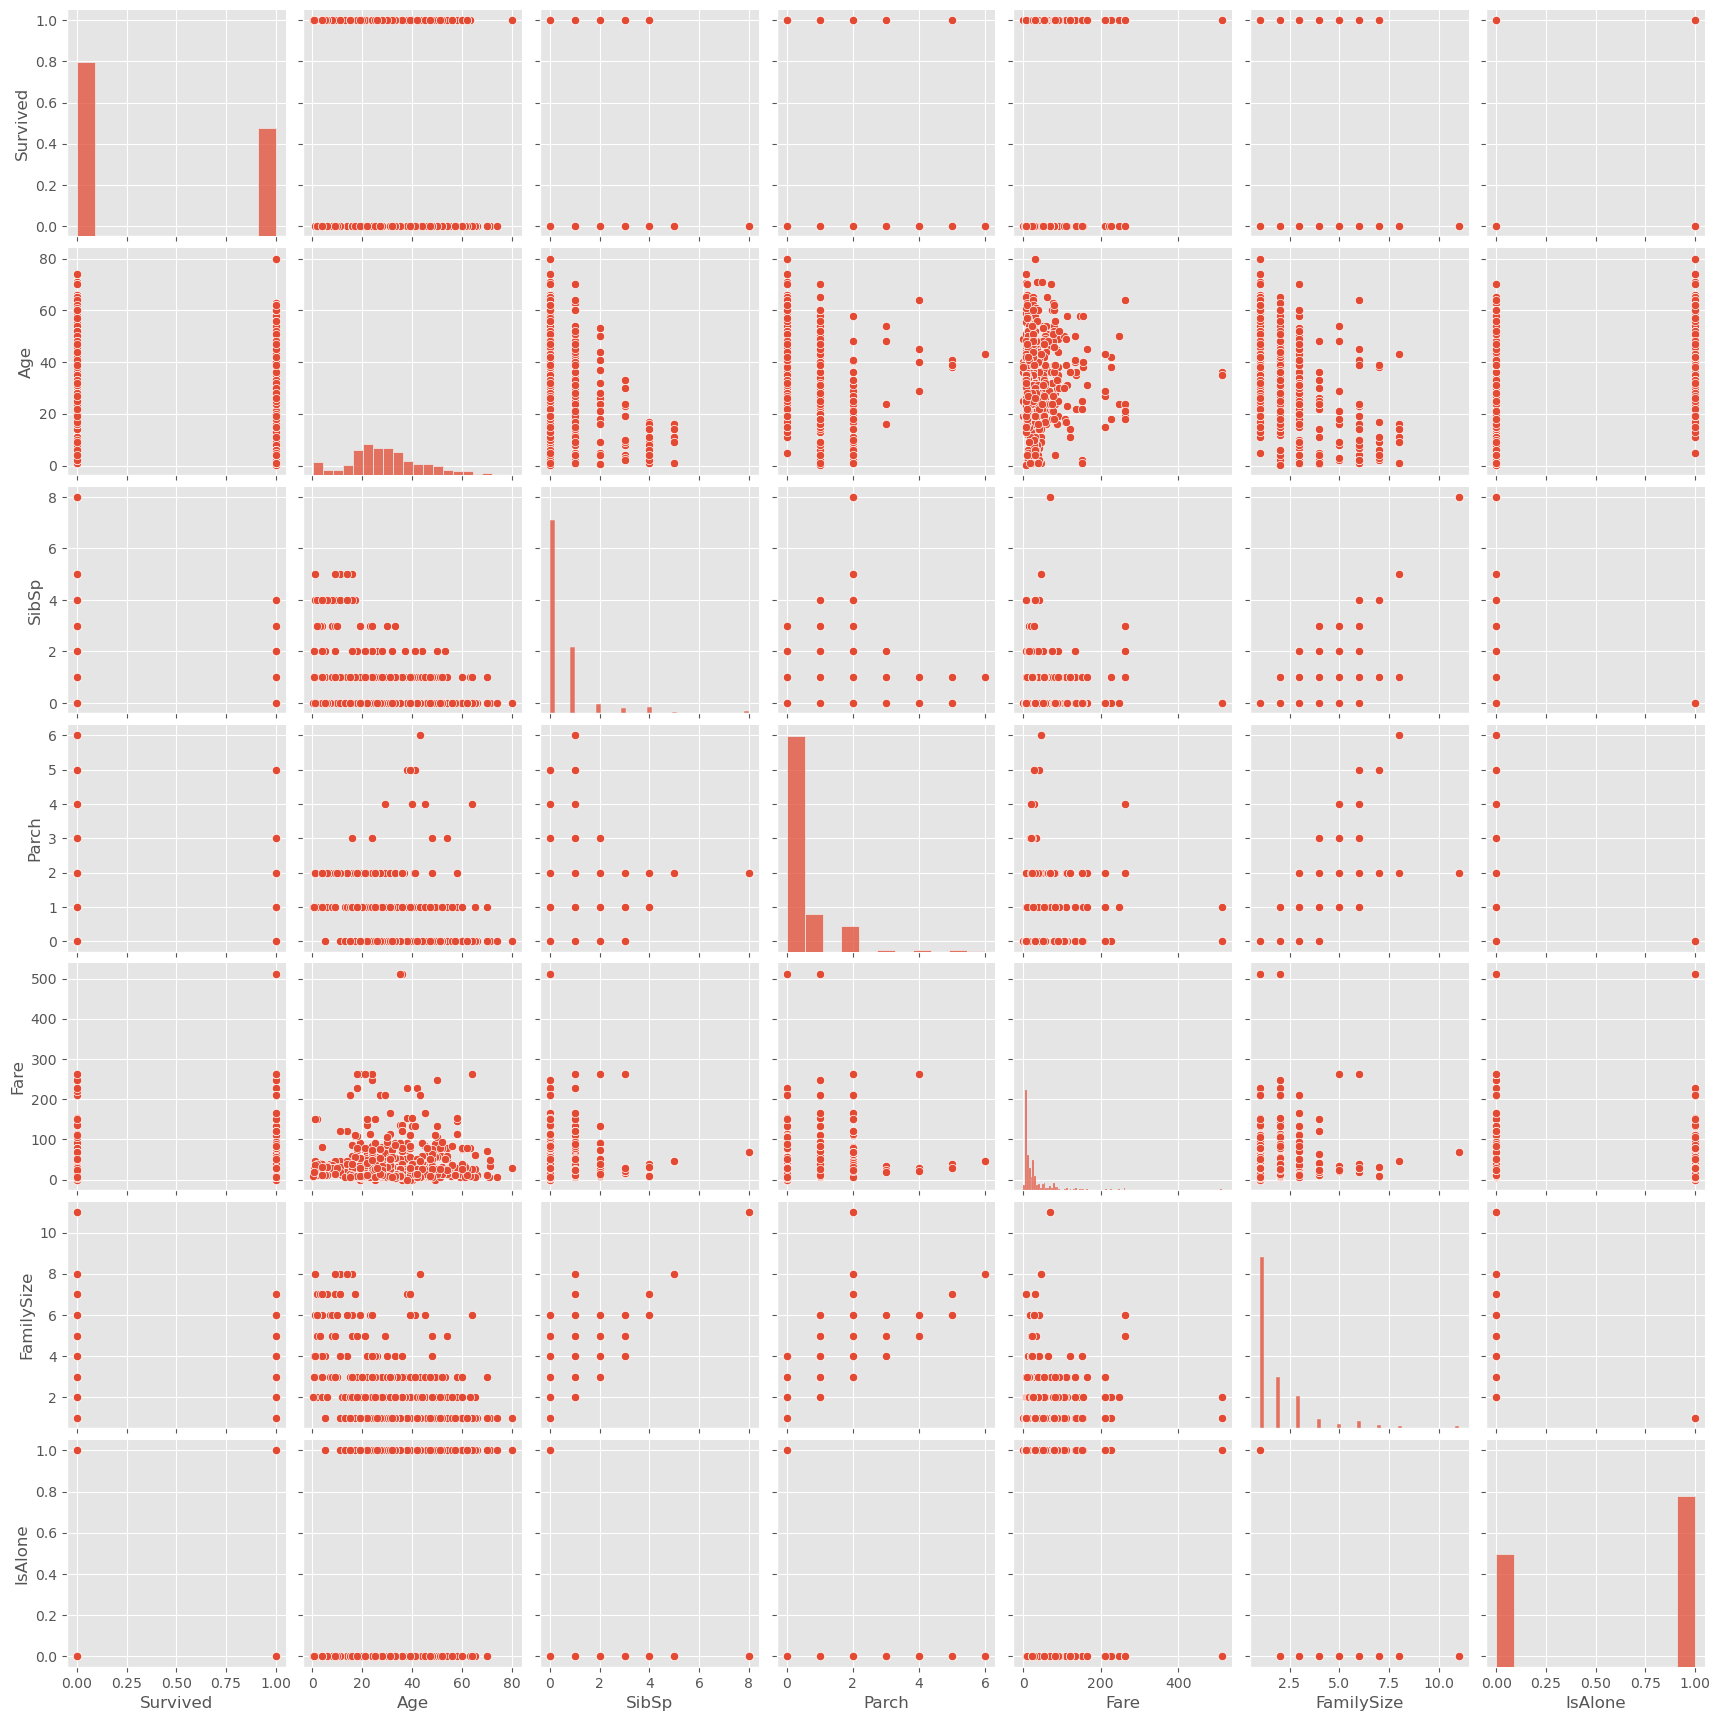

In [24]:
sns.pairplot(df[num_var])